<div style="background:linear-gradient(135deg,#7a3d00 0%,#b45309 55%,#d97706 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#ffe9c7;font-weight:700;text-transform:uppercase">Chapter 20 · Solutions</div>
  <div style="font-size:36px;font-weight:900;line-height:1.1;margin:10px 0 6px">Practice Challenges, Worked Answers ✅</div>
  <div style="font-size:15px;color:#ffe6cc;max-width:700px;line-height:1.6">Full solutions to the five "Handling Missing Data" challenges. Try them yourself first, then compare.</div>
  <div style="margin-top:16px;font-size:13px;color:#ffe2bf">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
rng = np.random.default_rng(202)
print("Ready.")

Ready.


<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0891b2;letter-spacing:1px">CHALLENGE 1 · NAME THE MECHANISM</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">MCAR, MAR, or MNAR?</div>
<div style="color:#4a5578;margin-top:6px">Classify the missingness in each scenario: (a) a scale randomly drops every 50th weight reading due to a firmware glitch; (b) people with higher incomes skip the income question; (c) men skip a survey item more often, and sex is recorded.</div>
</div>

In [2]:
answers = {
  "(a) random firmware glitch":      "MCAR: missingness unrelated to any value",
  "(b) high earners skip income":    "MNAR: depends on the unobserved income itself",
  "(c) men skip, sex is recorded":   "MAR:  depends on an OBSERVED variable (sex)",
}
for k,v in answers.items(): print(f"{k:34} -> {v}")

(a) random firmware glitch         -> MCAR: missingness unrelated to any value
(b) high earners skip income       -> MNAR: depends on the unobserved income itself
(c) men skip, sex is recorded      -> MAR:  depends on an OBSERVED variable (sex)


**Answer:** (a) **MCAR**, the glitch is unrelated to the data, so dropping those rows is unbiased; (b) **MNAR**, missingness depends on the very value that is missing (income), the hardest case, where standard imputation is biased; (c) **MAR**, missingness depends on an *observed* variable (sex), so imputation conditioning on sex can be approximately unbiased. You cannot read the mechanism off the data; it is a judgment from domain knowledge.

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">CHALLENGE 2 · COUNT THE GAPS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Sentinel to NaN, then audit</div>
<div style="color:#4a5578;margin-top:6px">This frame uses -1 for "missing" age. Convert it to NaN and report the count and percent missing per column.</div>
</div>

In [3]:
raw = pd.DataFrame({"age":[25,-1,40,-1,33,-1], "score":[88,72,np.nan,90,np.nan,67]})
df = raw.replace(-1, np.nan)
print("count missing:\n", df.isna().sum().to_string())
print("\npercent missing:\n", (df.isna().mean()*100).round(1).to_string())

count missing:
 age      3
score    2

percent missing:
 age      50.0
score    33.3


**Answer:** After `replace(-1, np.nan)`, **age** has 3 missing (50%) and **score** has 2 missing (~33%). The sentinel must become real NaN first, otherwise `isna()` sees nothing and `-1` silently drags the mean down. This is the bridge from Chapter 18 (hidden codes) and Chapter 19 (coercion creates NaN).

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#d97706;letter-spacing:1px">CHALLENGE 3 · DELETION COST</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">How much do you lose?</div>
<div style="color:#4a5578;margin-top:6px">For a 500-row frame where each of 3 columns is independently missing 10% of the time, how many COMPLETE rows survive listwise deletion? Compute it.</div>
</div>

In [4]:
n=500; df = pd.DataFrame(rng.normal(0,1,(n,3)), columns=list("abc"))
for col in df.columns:
    df.loc[rng.choice(n, int(0.10*n), replace=False), col] = np.nan
complete = len(df.dropna())
print(f"rows: {n}")
print(f"complete rows after dropna(): {complete}  (lost {n-complete} = {100*(n-complete)/n:.0f}%)")
print(f"(roughly 0.9^3 = {0.9**3:.2f} of rows expected to survive)")

rows: 500
complete rows after dropna(): 366  (lost 134 = 27%)
(roughly 0.9^3 = 0.73 of rows expected to survive)


**Answer:** With three columns each ~10% missing and independent, only about 0.9³ ≈ **73%** of rows are complete, so listwise deletion discards roughly a quarter of the data even though no single column is badly missing. Deletion costs compound across columns, which is why "just drop the NaNs" can quietly gut a dataset (and only stays unbiased under MCAR).

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#059669;letter-spacing:1px">CHALLENGE 4 · MEAN IMPUTATION COST</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Watch the variance shrink</div>
<div style="color:#4a5578;margin-top:6px">Take 300 values ~N(100, 20), blank out 40%, then mean-impute. Compare the standard deviation before and after, and explain what happened.</div>
</div>

In [5]:
full = rng.normal(100, 20, 300)
obs = full.copy(); obs[rng.choice(300, 120, replace=False)] = np.nan
filled = SimpleImputer(strategy="mean").fit_transform(obs.reshape(-1,1)).ravel()
print(f"true SD          : {full.std():.2f}")
print(f"observed SD      : {np.nanstd(obs):.2f}")
print(f"after mean impute: {filled.std():.2f}   <- shrunk")

true SD          : 19.36
observed SD      : 18.92
after mean impute: 14.65   <- shrunk


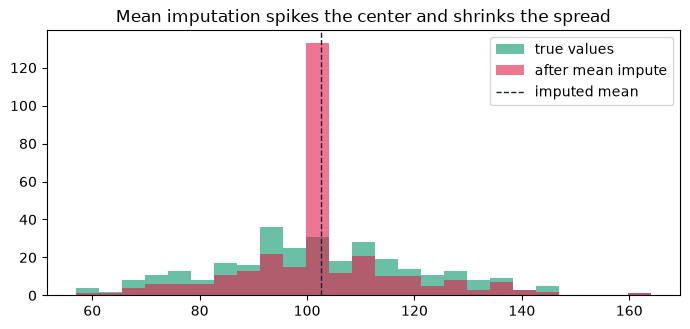

In [6]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.hist(full, bins=25, alpha=0.6, label="true values", color="#059669")
ax.hist(filled, bins=25, alpha=0.6, label="after mean impute", color="#e11d48")
ax.axvline(np.nanmean(obs), color="#1a2138", ls="--", lw=1, label="imputed mean")
ax.set(title="Mean imputation spikes the center and shrinks the spread"); ax.legend()
plt.tight_layout(); plt.show()

**Answer:** The imputed standard deviation drops well below the true ~20, because 40% of the values became the *same* number (the mean), adding a tall spike with zero spread. Mean imputation **understates variance** and **biases correlations toward zero**. It is fine as a quick baseline, but for anything inferential prefer a method that conditions on other variables (KNN, MICE), and remember even those understate uncertainty unless you do multiple imputation.

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#2563eb;letter-spacing:1px">CHALLENGE 5 · NO LEAKAGE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Fit on train, transform test</div>
<div style="color:#4a5578;margin-top:6px">Split a frame with missing values into train/test, then impute WITHOUT leaking. Show that the test set is filled with the value learned from the TRAINING data.</div>
</div>

In [7]:
from sklearn.model_selection import train_test_split
X = pd.DataFrame({"v": rng.normal(50,10,200)})
X.loc[rng.choice(200, 60, replace=False), "v"] = np.nan
Xtr, Xte = train_test_split(X, test_size=0.3, random_state=1)
imp = SimpleImputer(strategy="mean").fit(Xtr)         # learn from TRAIN only
train_mean = imp.statistics_[0]
Xte_filled = imp.transform(Xte)
filled_vals = Xte_filled[Xte["v"].isna().to_numpy()]
print(f"mean learned from train : {train_mean:.3f}")
print(f"value used to fill test  : {np.unique(filled_vals.round(3))}")
print(f"match? {np.allclose(filled_vals, train_mean)}")

mean learned from train : 48.744
value used to fill test  : [48.744]
match? True


**Answer:** The test gaps are all filled with the **training** mean, not a mean recomputed on the test set, exactly what `fit(Xtr)` then `transform(Xte)` guarantees. Fitting the imputer on the full dataset before splitting would let test information leak into training and inflate your scores. Same discipline as the scaler in Chapter 12; wrap it in a `Pipeline` so it happens automatically in cross-validation.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">🎉 Nicely done!</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">You classified the three missingness mechanisms, surfaced hidden gaps, measured the compounding cost of deletion, watched mean imputation shrink the variance, and imputed without leaking. You now choose a missing-data strategy on purpose, a core skill in the data-preparation toolkit.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>